## Loading packages

In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import spCLUE
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

spCLUE.fix_seed(100)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


## Loading data

In [2]:
sample_name="151671"
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'

# data_file = f"../dataset/DLPFC/{sample_name}.h5ad"
# adata = sc.read_h5ad(data_file)
adata = sc.read_visium(data_dir + sample_name)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
import pandas as pd

meta = pd.read_csv(
    data_dir+sample_name+"/metadata.tsv",
    sep="\t"
)

meta = meta.set_index("barcode")
adata.obs["Region"] = meta.loc[
    adata.obs_names,
    "layer_guess_reordered"
]
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())

Region
Layer3    1918
Layer6     760
Layer5     721
WM         449
Layer4     245
Name: count, dtype: int64
NA spots: 17


In [4]:
# adata = spCLUE.preprocess(adata)
# adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
# g_spatia = spCLUE.prepare_graph(adata, "spatial", n_neighbors=6)
# g_expr = spCLUE.prepare_graph(adata, "expr", metric="euclidean", n_neighbors=8)
# graph_dict = {"spatial": g_spatia, "expr":g_expr}

In [5]:
from spCLUE.preprocess import (
    prepare_euclidean_graph, 
    prepare_cosine_graph, 
    prepare_fused_graph
)

# 1. 数据预处理
adata = spCLUE.preprocess(adata, hvgNumber=3000)

# 2. 构建三个视图的图
g_spatial = prepare_euclidean_graph(adata,)
g_feature = prepare_cosine_graph(adata, k=14)
g_combined = prepare_fused_graph(g_spatial, g_feature)

# 3. 准备图字典
graph_dict = {
    "spatial": g_spatial,
    "feature": g_feature,
    "combined": g_combined,
}
use_zinb = True
# 如果使用ZINB解码器，需要提供raw count
if use_zinb:
    graph_dict["raw_count"] = adata.layers["count"].toarray()

Preprocessing starting according to CSMVL description...
Selecting top 3000 HVGs...
Normalizing total counts to 10,000...
Scaling and clipping at threshold 10...


In [6]:
# import numpy as np
# import scipy.sparse as sp

# def calculate_neighborhood_overlap(adata, graph_dict, key_added='adj_overlap'):
#     """
#     计算空间图与表达图的邻域交集率 (Jaccard Index)
#     J(i) = |Ns(i) ∩ Ne(i)| / |Ns(i) ∪ Ne(i)|
#     """
#     # 1. 获取两个图的稀疏矩阵
#     g_spatial = graph_dict['spatial']
#     g_expr = graph_dict['expr']
    
#     # 2. 预处理：转为CSR格式以便高效计算，并二值化
#     # 我们只关心“是否为邻居”，不关心权重大小，且必须去掉对角线（自环）
#     def to_binary_adjacency(adj):
#         # 复制以免修改原图
#         adj_bin = adj.copy().tocsr()
#         # 二值化：非零元素设为1
#         adj_bin.data[:] = 1
#         # 去掉对角线（计算邻居交集时不包含自己）
#         adj_bin.setdiag(0)
#         adj_bin.eliminate_zeros()
#         return adj_bin

#     bin_spatial = to_binary_adjacency(g_spatial)
#     bin_expr = to_binary_adjacency(g_expr)
    
#     # 3. 计算交集 (Intersection): 两个矩阵对应位置都为1
#     # 稀疏矩阵的 multiply 相当于逐元素相乘 (Element-wise multiplication)，即逻辑 AND
#     intersection_mat = bin_spatial.multiply(bin_expr)
#     # 按行求和，得到每个细胞的交集邻居数 |Ns ∩ Ne|
#     n_intersection = np.array(intersection_mat.sum(axis=1)).flatten()
    
#     # 4. 计算并集 (Union): |Ns ∪ Ne| = |Ns| + |Ne| - |Ns ∩ Ne|
#     n_spatial = np.array(bin_spatial.sum(axis=1)).flatten()
#     n_expr = np.array(bin_expr.sum(axis=1)).flatten()
#     n_union = n_spatial + n_expr - n_intersection
    
#     # 5. 计算 Jaccard Index
#     # 防止分母为0 (即没有任何邻居的情况)
#     jaccard_index = np.divide(
#         n_intersection, 
#         n_union, 
#         out=np.zeros_like(n_intersection, dtype=float), 
#         where=n_union != 0
#     )
    
#     # 6. 保存到 adata.obs
#     adata.obs[key_added] = jaccard_index
    
#     print(f"指标已计算并存入 adata.obs['{key_added}']")
#     print(f"平均一致率: {np.mean(jaccard_index):.4f}")
    
#     return jaccard_index

In [7]:
# # --- 执行计算 ---
# calculate_neighborhood_overlap(adata, graph_dict, key_added='adj_overlap')

# # 查看前几个结果
# print(adata.obs['adj_overlap'].head())

In [8]:
# import numpy as np
# import pandas as pd
# from scipy import sparse
# from sklearn.decomposition import PCA
# from sklearn.metrics import pairwise_distances

# def calculate_advanced_metrics(adata, graph_dict, spatial_key="spatial"):
#     """
#     计算邻域重叠的详细分布统计，以及交叉模态距离指标。
#     """
#     print("=== 开始计算高级评估指标 ===")
    
#     # -----------------------------
#     # 1. adj_overlap 分布统计
#     # -----------------------------
#     if 'adj_overlap' not in adata.obs:
#         print("警告: adata.obs 中未找到 'adj_overlap'，请先运行上一步的计算函数。")
#         return
    
#     overlap_values = adata.obs['adj_overlap'].values
    
#     # 计算统计量
#     stats = {
#         "Min": np.min(overlap_values),
#         "25%": np.percentile(overlap_values, 25),
#         "50% (Median)": np.median(overlap_values),
#         "75%": np.percentile(overlap_values, 75),
#         "Max": np.max(overlap_values),
#         "Mean": np.mean(overlap_values),
#         "Ratio > 0": np.mean(overlap_values > 0)  # 大于0的比例
#     }
    
#     print("\n[指标 1] adj_overlap 分布统计:")
#     print(f"  >0 的比例 (一致性覆盖度): {stats['Ratio > 0']:.2%}")
#     print(f"  中位数 (典型一致性): {stats['50% (Median)']:.4f}")
#     print(f"  均值: {stats['Mean']:.4f}")
#     print(f"  四分位数 [25%, 50%, 75%]: [{stats['25%']:.4f}, {stats['50% (Median)']:.4f}, {stats['75%']:.4f}]")

#     # -----------------------------
#     # 2. 准备特征数据
#     # -----------------------------
#     # 空间坐标
#     spatial_coords = adata.obsm[spatial_key]
    
#     # 表达特征：推荐使用 PCA 降维后的数据计算距离，比原始 count 更准且快
#     if 'X_pca' not in adata.obsm:
#         print("\n正在计算 PCA 用于表达距离计算...")
#         pca = PCA(n_components=50)
#         expr_features = pca.fit_transform(adata.X.toarray() if sparse.issparse(adata.X) else adata.X)
#         adata.obsm['X_pca'] = expr_features
#     else:
#         expr_features = adata.obsm['X_pca']

#     # -----------------------------
#     # 3. 定义交叉距离计算函数
#     # -----------------------------
#     def get_avg_neighbor_dist(graph, feature_matrix, metric_name):
#         """
#         计算每个细胞的邻居在指定特征空间中的平均距离
#         """
#         # 确保图是 CSR 格式，加速行切片
#         adj = graph.tocsr()
#         n_cells = adj.shape[0]
#         avg_dists = np.zeros(n_cells)
        
#         # 逐个细胞计算（为了节省内存，不生成巨大的距离矩阵）
#         # 如果数据量特别大 (>10w)，可以考虑用 numba 优化，但一般情况此循环够快
#         for i in range(n_cells):
#             # 获取邻居索引 (indices)
#             neighbor_indices = adj.indices[adj.indptr[i]:adj.indptr[i+1]]
            
#             if len(neighbor_indices) == 0:
#                 avg_dists[i] = np.nan # 孤立点
#                 continue
                
#             # 取出当前点和邻居点的特征
#             center_feat = feature_matrix[i, :].reshape(1, -1)
#             neighbor_feats = feature_matrix[neighbor_indices, :]
            
#             # 计算欧氏距离
#             dists = pairwise_distances(center_feat, neighbor_feats, metric='euclidean')
#             avg_dists[i] = np.mean(dists)
            
#         return avg_dists

#     # -----------------------------
#     # 4. 计算两个交叉均值
#     # -----------------------------
    
#     # A. 空间邻居在表达空间的平均距离 (expr_dist_of_spatial_neighbors)
#     # 含义：物理上挨着的细胞，长得像不像？
#     # 如果值很大 -> 空间异质性极高（如不同类型细胞混杂）或表达噪声大
#     dist_expr_of_spatial = get_avg_neighbor_dist(graph_dict['spatial'], expr_features, "Expr Dist")
#     adata.obs['expr_dist_of_spatial_neighbors'] = dist_expr_of_spatial
    
#     # B. 表达邻居在空间的平均距离 (spatial_dist_of_expr_neighbors)
#     # 含义：表达上像的细胞，住得近不近？
#     # 如果值很大 -> 细胞类型在空间上非常弥散，没有形成局部聚集
#     dist_spatial_of_expr = get_avg_neighbor_dist(graph_dict['expr'], spatial_coords, "Spatial Dist")
#     adata.obs['spatial_dist_of_expr_neighbors'] = dist_spatial_of_expr

#     print("\n[指标 2] 交叉模态距离计算完成:")
#     print(f"  空间邻居的表达差异 (Mean Expr Dist of Spatial Neighbors): {np.nanmean(dist_expr_of_spatial):.4f}")
#     print(f"  表达邻居的空间跨度 (Mean Spatial Dist of Expr Neighbors): {np.nanmean(dist_spatial_of_expr):.4f}")
    
#     return stats

# # ==========================================
# # 运行代码
# # ==========================================
# # 假设 adata 和 graph_dict 已经准备好
# _ = calculate_advanced_metrics(adata, graph_dict)

In [9]:
# import matplotlib.pyplot as plt

# # 1. 空间分布图：观察低值区域（颜色较深/较冷的点）
# sc.pl.spatial(
#     adata, 
#     color="adj_overlap", 
#     cmap="RdYlBu_r",  # 红色高(一致性好)，蓝色低(冲突大)
#     title="Neighborhood Jaccard Index (Consistency)",
#     size=1.5,
#     vmin=0, vmax=0.5 # 这里的vmax可以根据数据实际分布调整，通常交集率不会特别高
# )

# # 2. (可选) 直方图：看整体分布情况
# plt.hist(adata.obs['adj_overlap'], bins=50)
# plt.title("Distribution of Neighborhood Overlap")
# plt.xlabel("Jaccard Index")
# plt.ylabel("Cell Count")
# plt.show()

In [10]:
# import scanpy as sc

# # 绘制两个新指标的空间分布
# sc.pl.spatial(
#     adata, 
#     color=['adj_overlap', 'expr_dist_of_spatial_neighbors', 'spatial_dist_of_expr_neighbors'],
#     cmap='viridis',
#     size=1.5,
#     ncols=3,
#     title=['Overlap (Consistency)', 'Local Heterogeneity (Expr Dist)', 'Spatial Dispersion (Spatial Dist)']
# )

In [11]:
# import numpy as np
# import pandas as pd
# from scipy import sparse

# def calculate_label_consistency(adata, graph_dict, label_key, key_suffix=""):
#     """
#     计算空间图和表达图中，邻居标签与自身标签一致的比例。
    
#     参数:
#         adata: AnnData 对象
#         graph_dict: 包含 'spatial' 和 'expr' 稀疏矩阵的字典
#         label_key: adata.obs 中存储聚类标签的列名 (例如 'spCLUE', 'leiden')
#         key_suffix: 结果列名的后缀 (可选)
#     """
#     if label_key not in adata.obs:
#         raise KeyError(f"在 adata.obs 中找不到标签列: {label_key}")
    
#     print(f"===正在基于标签 '{label_key}' 计算邻域一致性===")
    
#     # 获取标签并确保是 numpy 数组
#     labels = adata.obs[label_key].values
    
#     # 遍历两个图
#     results = {}
#     for graph_type in ['spatial', 'expr']:
#         if graph_type not in graph_dict:
#             continue
            
#         print(f"正在计算 {graph_type} 图的一致性...")
        
#         # 获取邻接矩阵 (CSR 格式加速行读取)
#         adj = graph_dict[graph_type].tocsr()
#         n_cells = adata.shape[0]
        
#         consistency_scores = np.zeros(n_cells, dtype=float)
        
#         # 逐个细胞计算
#         for i in range(n_cells):
#             # 获取第 i 个细胞的邻居索引
#             # indices[start:end] 获取的是 CSR 矩阵第 i 行的所有非零元素列号（即邻居ID）
#             start_ptr = adj.indptr[i]
#             end_ptr = adj.indptr[i+1]
#             neighbor_indices = adj.indices[start_ptr:end_ptr]
            
#             # 如果没有邻居 (孤立点)，设为 NaN 或 0
#             if len(neighbor_indices) == 0:
#                 consistency_scores[i] = np.nan
#                 continue
            
#             # 获取自身标签和邻居标签
#             self_label = labels[i]
#             neighbor_labels = labels[neighbor_indices]
            
#             # 计算一致的邻居数量
#             # 注意：如果 labels 是 categorical 类型，numpy 比较依然有效
#             match_count = np.sum(neighbor_labels == self_label)
            
#             # 计算比例
#             consistency_scores[i] = match_count / len(neighbor_indices)
        
#         # 保存结果名称
#         save_key = f"{graph_type}_label_consistency{key_suffix}"
#         adata.obs[save_key] = consistency_scores
#         results[graph_type] = save_key
        
#         # 打印统计信息
#         print(f"  [{graph_type}] 平均一致性: {np.nanmean(consistency_scores):.4f}")
#         print(f"  [{graph_type}] 中位数一致性: {np.nanmedian(consistency_scores):.4f}")

#     return results

# # ==========================================
# # 使用示例
# # ==========================================
# # 请确保 'spCLUE' (或你的聚类列名) 已经在 adata.obs 中
# # 并且 graph_dict 已经通过 prepare_graph 生成

# # 假设你的聚类标签列叫 'spCLUE' (或者是 'leiden', 'clusters' 等)
# target_label = 'Region'  

# # 运行计算
# calculate_label_consistency(adata, graph_dict, label_key=target_label)

# # 查看前几行结果
# cols = ['spatial_label_consistency', 'expr_label_consistency']
# print(adata.obs[cols].head())

## train spCLUE

In [12]:
spCLUE_model = spCLUE.spCLUE(
    input_data=adata.X,
    graph_dict=graph_dict,
    n_clusters=n_clusters,
    lambda_ccr=5.0,  # CCR损失权重
    use_zinb=True,  # 是否使用ZINB解码器
    # kappa=0.1,
    beta=1.0,
    gamma=1.0,
)
_, adata.obsm["spCLUE"], attention_weights = spCLUE_model.train()

Training Start (Enhanced 3-View with CCR) =========================>


  3%|▎         | 13/500 [00:01<00:41, 11.81it/s]

epoch 10: ARI=0.0866, CCR=0.3966, CLU=2.1916, REC=1.3932


  4%|▍         | 22/500 [00:02<00:26, 17.86it/s]

epoch 20: ARI=0.1717, CCR=0.3184, CLU=2.1517, REC=1.1570


...

epoch 230: ARI=0.6501, CCR=0.1545, CLU=0.2620, REC=0.7502


 49%|████▉     | 244/500 [00:13<00:12, 20.68it/s]

epoch 240: ARI=0.6600, CCR=0.1529, CLU=0.2433, REC=0.7466


 50%|████▉     | 249/500 [00:13<00:13, 18.63it/s]

epoch 250: ARI=0.6627, CCR=0.1508, CLU=0.2321, REC=0.7433


In [13]:
import torch
import numpy as np

# 假设 model_output 是 forward 的返回结果
# attention_weights 是返回元组的最后一个元素
weights = attention_weights # shape: [N, 3]

print("=== Attention Weights Statistics ===")
print(f"Shape: {weights.shape}")

# 1. 检查是否有 NaN 或 Inf
if np.isnan(weights).any() or np.isinf(weights).any():
    print("WARNING: Weights contain NaN or Inf!")

# 2. 检查全局平均权重 (查看模型整体偏好哪个视图)
# Column 0: Spatial, Column 1: Feature, Column 2: Combined
mean_weights = np.mean(weights, axis=0)
print(f"Global Mean - Spatial: {mean_weights[0]:.4f}, Feature: {mean_weights[1]:.4f}, Combined: {mean_weights[2]:.4f}")

# 3. 检查样本间的方差 (查看模型是否对不同细胞有不同的关注点)
std_weights = np.std(weights, axis=0)
print(f"Global Std  - Spatial: {std_weights[0]:.4f}, Feature: {std_weights[1]:.4f}, Combined: {std_weights[2]:.4f}")

# 4. 检查是否归一化 (Softmax 输出的和应该接近 1)
row_sums = np.sum(weights, axis=1)
print(f"Row Sums (First 5): {row_sums[:5]}") # 应该全是 1.0

=== Attention Weights Statistics ===
Shape: (4110, 3)
Global Mean - Spatial: 0.2914, Feature: 0.2818, Combined: 0.4268
Global Std  - Spatial: 0.0319, Feature: 0.0451, Combined: 0.0755
Row Sums (First 5): [1.         1.         0.99999994 1.         1.        ]


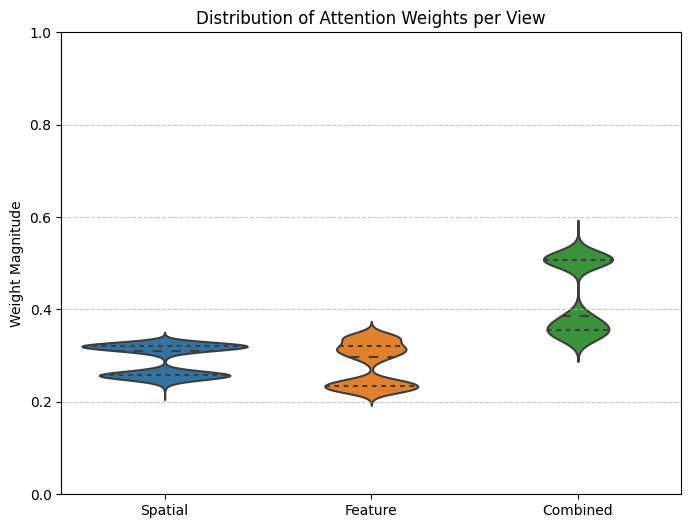

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 创建 DataFrame 方便绘图
df_weights = pd.DataFrame(weights, columns=['Spatial', 'Feature', 'Combined'])

plt.figure(figsize=(8, 6))
# 使用小提琴图可以看到密度分布，箱线图可以看到中位数和离群值
sns.violinplot(data=df_weights, inner="quartile")
plt.title("Distribution of Attention Weights per View")
plt.ylabel("Weight Magnitude")
plt.ylim(0, 1)  # 假设经过了 Softmax
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
# spCLUE_model = spCLUE.spCLUE(adata.obsm["X_pca"], graph_dict, n_clusters,kappa=1)
# _,adata.obsm["spCLUE"],_,  att_beta = spCLUE_model.train()

In [16]:
# import scanpy as sc
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. 处理 att_beta
# # 假设 att_beta 是 tensor 或 numpy array，形状为 (N, 2, 1)
# # 确保转为 numpy
# if hasattr(att_beta, 'detach'):
#     att_beta = att_beta.detach().cpu().numpy()
    
# # 去掉最后一个维度 -> (N, 2)
# att_beta = att_beta.squeeze(-1) 

# # 假设第0维是空间视图权重，第1维是表达视图权重
# # (根据你代码中 stack 的顺序: z_stack = torch.stack([z_spatial_norm, z_expr_norm], dim=1))
# spa_weight = att_beta[:, 0]
# expr_weight = att_beta[:, 1]

# # 2. 存入 adata.obs
# adata.obs['Spatial_Weight'] = spa_weight
# adata.obs['Expr_Weight'] = expr_weight

# # 3. 可视化
# # 调整点的大小 (size) 和颜色图 (cmap)
# fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# sc.pl.spatial(adata, color='Spatial_Weight', cmap='viridis', size=1.5, ax=axs[0], show=False, title='Attention to Spatial View')
# sc.pl.spatial(adata, color='Expr_Weight', cmap='magma', size=1.5, ax=axs[1], show=False, title='Attention to Expression View')

# plt.tight_layout()
# plt.show()

In [17]:
# plt.figure(figsize=(6, 4))
# plt.hist(spa_weight, bins=50, alpha=0.7, label='Spatial View', color='blue')
# plt.hist(expr_weight, bins=50, alpha=0.7, label='Expression View', color='orange')
# plt.title('Distribution of Attention Weights')
# plt.xlabel('Weight')
# plt.ylabel('Frequency')
# plt.legend()
# plt.show()

In [18]:
# 确保你已经有了聚类标签，例如 'spCLUE_labels'
# sc.pl.violin(adata, keys=['Spatial_Weight', 'Expr_Weight'], groupby="spCLUE", rotation=90)

In [19]:
refinement = True
cluster_method = "mclust"
pred = spCLUE.clustering(
    adata,
    n_clusters,
    key="spCLUE",
    refinement=refinement,
    cluster_methods=cluster_method,
)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [20]:
adata = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI on {sample_name}: {ARI}")

ARI on 151671: 0.5325230778355472


## visualization

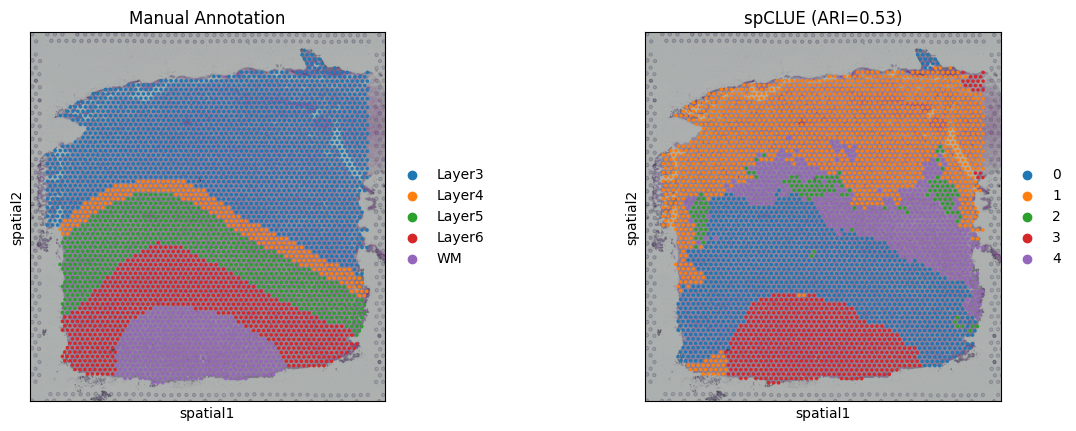

In [21]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"spCLUE (ARI={round(ARI, 2)})"])